# β-VAE: Disentangling Cell Cycle from Drug Response

## Real-World Scenario: Pulling Apart Two Confounded Biological Factors

**From PML-2 Chapter 21.3.1**

In a typical high-content single-cell experiment we vary the **drug dose** $d$ applied to a culture and then sequence the cells. Each cell's gene-expression vector $\mathbf{x}$ depends not only on the dose but also on the **cell cycle phase** $\varphi$ the cell was caught in. Without intervention the two factors will mix in any unsupervised embedding — PCA / standard VAE latents end up rotated combinations of phase and dose, which is bad for downstream interpretation and causal analysis.

We would like a generative model whose latent dimensions correspond to *separate* biological factors: $z_1$ tracks phase, $z_2$ tracks dose. That's exactly what §21.3.1's **β-VAE** is meant to encourage. The trick is a single hyperparameter:

$$\mathcal{L}_\beta(\boldsymbol{\theta}, \boldsymbol{\phi}\mid \mathbf{x}) = \underbrace{-\mathbb{E}_{q_{\boldsymbol{\phi}}(\mathbf{z}\mid\mathbf{x})}\!\left[\log p_{\boldsymbol{\theta}}(\mathbf{x}\mid\mathbf{z})\right]}_{\mathcal{L}_E\ \text{(reconstruction error)}} \; + \; \beta\,\underbrace{D_{\mathrm{KL}}\!\left(q_{\boldsymbol{\phi}}(\mathbf{z}\mid\mathbf{x})\,\|\,p_{\boldsymbol{\theta}}(\mathbf{z})\right)}_{\mathcal{L}_R\ \text{(KL regularizer)}}$$

When $\beta = 1$ we recover the standard VAE; $\beta = 0$ gives an autoencoder; $\beta > 1$ pushes the aggregate posterior toward the factorized prior, making each latent dimension more independent. This notebook implements the β-VAE for our scRNA-seq-style data, sweeps $\beta$ along the rate-distortion curve, and shows that $\beta > 1$ buys disentanglement at the cost of reconstruction fidelity — exactly the trade-off described in §21.3.1.

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
np.random.seed(0)

plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'
%matplotlib inline

## Key Formulas from PML-2 §21.3.1

### The β-VAE objective (Eq. 21.24)
$$\mathcal{L}_\beta(\boldsymbol{\theta}, \boldsymbol{\phi}\mid \mathbf{x}) = -\mathbb{E}_{q_{\boldsymbol{\phi}}(\mathbf{z}\mid\mathbf{x})}\!\left[\log p_{\boldsymbol{\theta}}(\mathbf{x}\mid\mathbf{z})\right] + \beta\,D_{\mathrm{KL}}\!\left(q_{\boldsymbol{\phi}}(\mathbf{z}\mid\mathbf{x})\,\|\,p_{\boldsymbol{\theta}}(\mathbf{z})\right)$$

### Why blurry / sharp reconstructions (Eq. 21.23)
For a Gaussian decoder with fixed variance, the log-likelihood is $-\tfrac{1}{2\sigma^2}\|\mathbf{x} - d_{\boldsymbol{\theta}}(\mathbf{z})\|_2^2$, so the optimal decoder predicts the *average* of all inputs that get mapped to $\mathbf{z}$. A large $\beta$ forces the encoder to map many distinct inputs to nearby $\mathbf{z}$'s, which averages out fine detail. A small $\beta$ lets each input claim its own pocket of latent space, which preserves detail but makes the prior a bad model of where data live.

### Total correlation (Eq. 21.25)
$$\mathrm{TC}(\mathbf{z}) = \sum_k \mathbb{H}(z_k) - \mathbb{H}(\mathbf{z}) = D_{\mathrm{KL}}\!\left(p(\mathbf{z}) \,\|\, \prod_k p_k(z_k)\right)$$

This is zero iff the components of $\mathbf{z}$ are mutually independent. The aggregate posterior $p(\mathbf{z}) = \mathbb{E}_{p_\mathcal{D}(\mathbf{x})}[q_{\boldsymbol{\phi}}(\mathbf{z}\mid\mathbf{x})]$ is what's pushed toward the factorized prior by the KL term, so a larger $\beta$ should drive TC down (Achille & Soatto, 2018, as cited in §21.3.1.1).

### Rate–distortion tradeoff (§21.3.1, second paragraph)
Varying $\beta$ from 0 to $\infty$ traces a curve:
- $\beta \downarrow$ → lower distortion $\mathcal{L}_E$, higher rate $\mathcal{L}_R$ (more bits stored per cell, sharper reconstructions)
- $\beta \uparrow$ → higher distortion, lower rate (more compressed, smoother latent, more disentangled)

We will reproduce a discrete version of this curve below.

## Step 1: Simulate scRNA-seq with Two Independent Latent Factors

We synthesize $N = 4000$ cells in $D = 30$ genes. Each cell carries two independent **ground-truth** factors:
- $\varphi \in [0, 2\pi)$ — cell-cycle phase (angular, encoded via $\sin\varphi$, $\cos\varphi$).
- $d \in [0, 1]$ — drug dose.

Each gene $g$ has a smooth response that mixes both factors:
$$x_g = a_g \cos(\varphi - \omega_g) + b_g\, d + c_g\, \cos(\varphi)\, d + \eta_g, \qquad \eta_g \sim \mathcal{N}(0, 0.15^2),$$
with $a_g, b_g, c_g, \omega_g$ drawn once and held fixed. Notice the cross term $\cos(\varphi) d$ — that's what makes simple PCA give *tangled* loadings, because the two factors are jointly expressed in many genes.

The model never sees $\varphi$ or $d$. We only use them at evaluation time to check disentanglement.

X shape: (4000, 30), mean: -0.000, std: 1.000


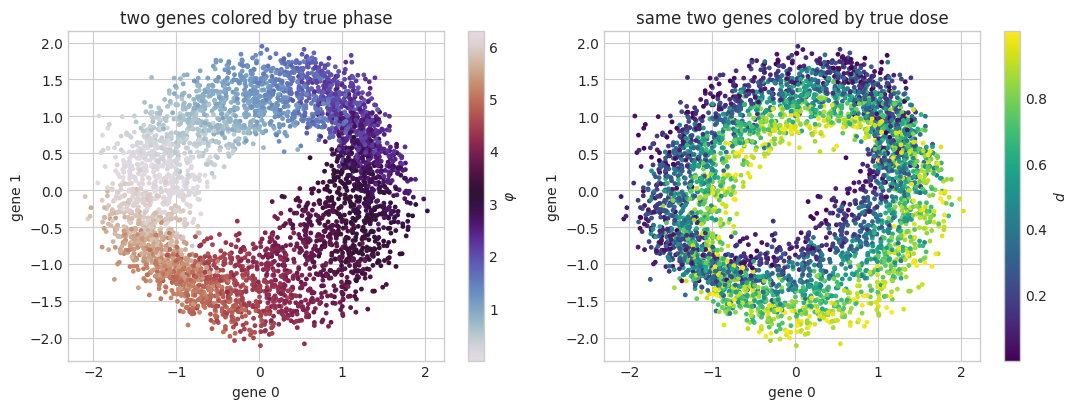

In [2]:
D = 30          # number of genes
N = 4000        # number of cells

rng = np.random.default_rng(0)

# True latent factors (these are what we hope to recover, but the VAE never sees them).
phase_true = rng.uniform(0.0, 2 * np.pi, size=N)
dose_true  = rng.uniform(0.0, 1.0,        size=N)

# Gene-specific response parameters (drawn once).
amp_phase  = rng.uniform(0.5, 1.5, size=D)
phase_shift = rng.uniform(0.0, 2 * np.pi, size=D)
amp_dose   = rng.uniform(-1.2, 1.2, size=D)
amp_cross  = rng.uniform(-0.6, 0.6, size=D)

# Build the expression matrix.
phase_term = amp_phase[None, :] * np.cos(phase_true[:, None] - phase_shift[None, :])
dose_term  = amp_dose[None, :]  * dose_true[:, None]
cross_term = amp_cross[None, :] * np.cos(phase_true[:, None]) * dose_true[:, None]
noise      = rng.normal(0.0, 0.15, size=(N, D))

X = (phase_term + dose_term + cross_term + noise).astype(np.float32)

# Standardize per gene so the Gaussian decoder with fixed variance is well-scaled.
X = (X - X.mean(0)) / X.std(0)

print(f"X shape: {X.shape}, mean: {X.mean():.3f}, std: {X.std():.3f}")

# Quick look: scatter of a couple of genes colored by each true factor.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sc0 = axes[0].scatter(X[:, 0], X[:, 1], s=6, c=phase_true, cmap='twilight')
axes[0].set_title('two genes colored by true phase')
axes[0].set_xlabel('gene 0'); axes[0].set_ylabel('gene 1')
plt.colorbar(sc0, ax=axes[0], label=r'$\varphi$')
sc1 = axes[1].scatter(X[:, 0], X[:, 1], s=6, c=dose_true, cmap='viridis')
axes[1].set_title('same two genes colored by true dose')
axes[1].set_xlabel('gene 0'); axes[1].set_ylabel('gene 1')
plt.colorbar(sc1, ax=axes[1], label=r'$d$')
plt.tight_layout(); plt.show()

Neither factor is visible from raw gene-pair scatter — both factors paint the same cloud differently. The job of the VAE is to find a low-dimensional code that separates them.

## Step 2: Encoder, Decoder, and the β-VAE Loss

We use:
- a **diagonal** Gaussian encoder $q_{\boldsymbol{\phi}}(\mathbf{z}\mid\mathbf{x}) = \mathcal{N}(\boldsymbol{\mu}, \mathrm{diag}(\boldsymbol{\sigma}^2))$ — simpler than the full-covariance one of §21.2.1, fine for disentanglement experiments;
- a **Gaussian decoder** with fixed observation variance $\sigma_x^2$ — this is the case where the rate–distortion intuition of §21.3.1 cleanly applies (Eq. 21.23);
- the prior $p(\mathbf{z}) = \mathcal{N}(\mathbf{0}, \mathbf{I})$ with $K = 4$ latents (over-parameterized on purpose: the model should *choose* to use only two of them).

The diagonal-Gaussian-to-standard-Normal KL has a closed form, which makes the β-VAE loss compact:
$$D_{\mathrm{KL}}\!\left(\mathcal{N}(\boldsymbol{\mu}, \mathrm{diag}(\boldsymbol{\sigma}^2))\,\|\,\mathcal{N}(\mathbf{0},\mathbf{I})\right) = \tfrac{1}{2}\sum_k \left[\mu_k^2 + \sigma_k^2 - 1 - 2\log\sigma_k\right].$$

In [3]:
K = 4           # latent dim (intentionally larger than 2)
H = 64          # hidden width
SIGMA_X = 0.5   # fixed observation noise std for the Gaussian decoder

class Encoder(nn.Module):
    def __init__(self, d_in=D, k=K, hidden=H):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(d_in, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.head_mu        = nn.Linear(hidden, k)
        self.head_log_sigma = nn.Linear(hidden, k)

    def forward(self, x):
        h = self.body(x)
        return self.head_mu(h), self.head_log_sigma(h).clamp(-7.0, 7.0)

class Decoder(nn.Module):
    def __init__(self, k=K, d_out=D, hidden=H):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(k, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, d_out),
        )

    def forward(self, z):
        return self.net(z)

def beta_vae_loss(x, encoder, decoder, beta):
    # Returns (-ELBO_beta, recon, kl) averaged per cell.
    mu, log_sigma = encoder(x)
    sigma = log_sigma.exp()

    eps = torch.randn_like(mu)
    z = mu + sigma * eps                                            # reparameterization

    x_hat = decoder(z)

    # Gaussian NLL with fixed variance, summed over genes.
    recon = 0.5 * ((x - x_hat) ** 2).sum(-1) / SIGMA_X**2
    recon = recon + 0.5 * D * np.log(2 * np.pi * SIGMA_X**2)         # constant term

    # Closed-form KL to N(0, I), summed over latent dims.
    kl = 0.5 * (mu**2 + sigma**2 - 1.0 - 2.0 * log_sigma).sum(-1)

    loss = (recon + beta * kl).mean()
    return loss, recon.mean().detach(), kl.mean().detach()

## Step 3: Train at Several Values of β

We train independent models at $\beta \in \{0.1, 0.5, 1.0, 4.0, 16.0\}$. Each model sees the same data but the loss reweighting changes how it uses its latent budget.

In [4]:
X_t = torch.tensor(X)
betas = [0.1, 0.5, 1.0, 4.0, 16.0]
epochs = 80
batch_size = 128

def train(beta, seed=0):
    torch.manual_seed(seed)
    enc = Encoder()
    dec = Decoder()
    opt = torch.optim.Adam(list(enc.parameters()) + list(dec.parameters()), lr=2e-3)
    history = {'loss': [], 'recon': [], 'kl': []}
    for ep in range(epochs):
        perm = torch.randperm(N)
        l_sum = r_sum = k_sum = 0.0
        nb = 0
        for start in range(0, N, batch_size):
            idx = perm[start:start + batch_size]
            x = X_t[idx]
            opt.zero_grad()
            loss, recon, kl = beta_vae_loss(x, enc, dec, beta)
            loss.backward(); opt.step()
            l_sum += loss.item(); r_sum += recon.item(); k_sum += kl.item(); nb += 1
        history['loss'].append(l_sum / nb)
        history['recon'].append(r_sum / nb)
        history['kl'].append(k_sum / nb)
    return enc, dec, history

models = {}
for beta in betas:
    enc, dec, hist = train(beta)
    models[beta] = {'enc': enc, 'dec': dec, 'hist': hist}
    print(f"β = {beta:>5.2f}  recon = {hist['recon'][-1]:7.2f}  KL = {hist['kl'][-1]:6.3f}  -ELBO_β = {hist['loss'][-1]:7.2f}")

β =  0.10  recon =    9.70  KL =  8.119  -ELBO_β =   10.52


β =  0.50  recon =   10.31  KL =  5.259  -ELBO_β =   12.94


β =  1.00  recon =   10.89  KL =  4.407  -ELBO_β =   15.30


β =  4.00  recon =   13.70  KL =  2.668  -ELBO_β =   24.38


β = 16.00  recon =   26.75  KL =  1.249  -ELBO_β =   46.74


## Step 4: The Rate–Distortion Curve

Plotting the final reconstruction term against the final KL term traces a discrete version of the rate–distortion curve from §21.3.1 (paragraph after Eq. 21.24). Moving along the curve corresponds to spending more or fewer bits per cell:
- low $\beta$ → high KL ($\mathcal{L}_R$ = rate) and low reconstruction ($\mathcal{L}_E$ = distortion);
- high $\beta$ → the encoder ends up close to the prior (low KL) but reconstructions are blurry.

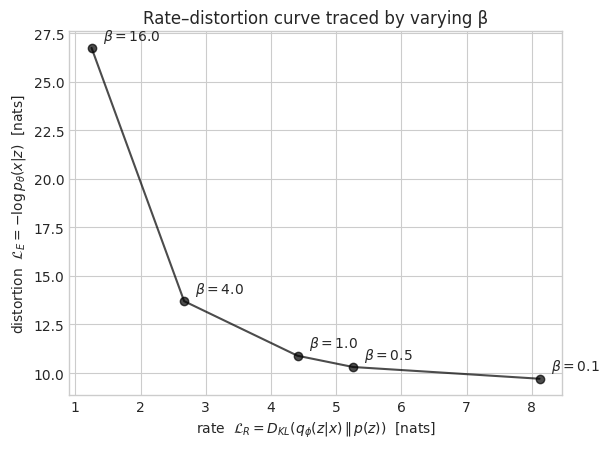

In [5]:
rates     = [models[b]['hist']['kl'][-1]    for b in betas]
distortions = [models[b]['hist']['recon'][-1] for b in betas]

fig, ax = plt.subplots(figsize=(6.2, 4.6))
ax.plot(rates, distortions, '-o', color='black', alpha=0.7)
for b, r, dist in zip(betas, rates, distortions):
    ax.annotate(rf'$\beta = {b}$', (r, dist),
                textcoords='offset points', xytext=(8, 6), fontsize=10)
ax.set_xlabel(r'rate  $\mathcal{L}_R = D_{KL}(q_\phi(z|x)\,\|\,p(z))$  [nats]')
ax.set_ylabel(r'distortion  $\mathcal{L}_E = -\log p_\theta(x|z)$  [nats]')
ax.set_title('Rate–distortion curve traced by varying β')
plt.tight_layout(); plt.show()

## Step 5: Which Latent Dimensions are Active?

A common diagnostic is the per-dimension KL contribution averaged over the data: $\mathrm{KL}_k = \mathbb{E}_{p_\mathcal{D}(\mathbf{x})}[\tfrac{1}{2}(\mu_k^2 + \sigma_k^2 - 1 - 2\log\sigma_k)]$.

If $\mathrm{KL}_k \approx 0$, then for that dimension the encoder has matched the prior — i.e. it carries no information about $\mathbf{x}$ ("posterior collapse"). With $K=4$ latents but only **two** true factors, we expect roughly two active dimensions per model. As $\beta$ grows the model is pushed toward collapsing as many dimensions as it can get away with.

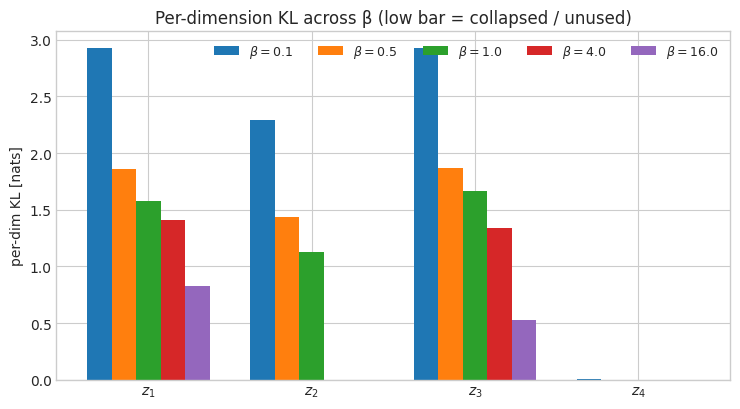

In [6]:
def per_dim_kl(enc, x_t):
    with torch.no_grad():
        mu, log_sigma = enc(x_t)
        sigma = log_sigma.exp()
        kl = 0.5 * (mu**2 + sigma**2 - 1.0 - 2.0 * log_sigma)
        return kl.mean(0).numpy()

fig, ax = plt.subplots(figsize=(7.5, 4.2))
width = 0.15
x_pos = np.arange(K)
for i, beta in enumerate(betas):
    kl_per_dim = per_dim_kl(models[beta]['enc'], X_t)
    ax.bar(x_pos + (i - 2) * width, kl_per_dim, width=width, label=rf'$\beta = {beta}$')
ax.set_xticks(x_pos)
ax.set_xticklabels([rf'$z_{k+1}$' for k in range(K)])
ax.set_ylabel('per-dim KL [nats]')
ax.set_title('Per-dimension KL across β (low bar = collapsed / unused)')
ax.legend(fontsize=9, ncols=5)
plt.tight_layout(); plt.show()

## Step 6: Disentanglement — Latent Codes Colored by True Factors

For each model we pick the two most active latent dimensions and scatter the posterior means $\boldsymbol{\mu}_{\boldsymbol{\phi}}(\mathbf{x})$ for all cells, colored by either the true phase or the true dose.

**The disentanglement criterion**: with $\beta = 1$ (standard VAE) the colors will typically swirl across both axes — phase and dose are mixed across $z_1, z_2$. With $\beta = 4$ or higher, one axis should align with phase and the other with dose — each latent now corresponds to a *single* biological factor.

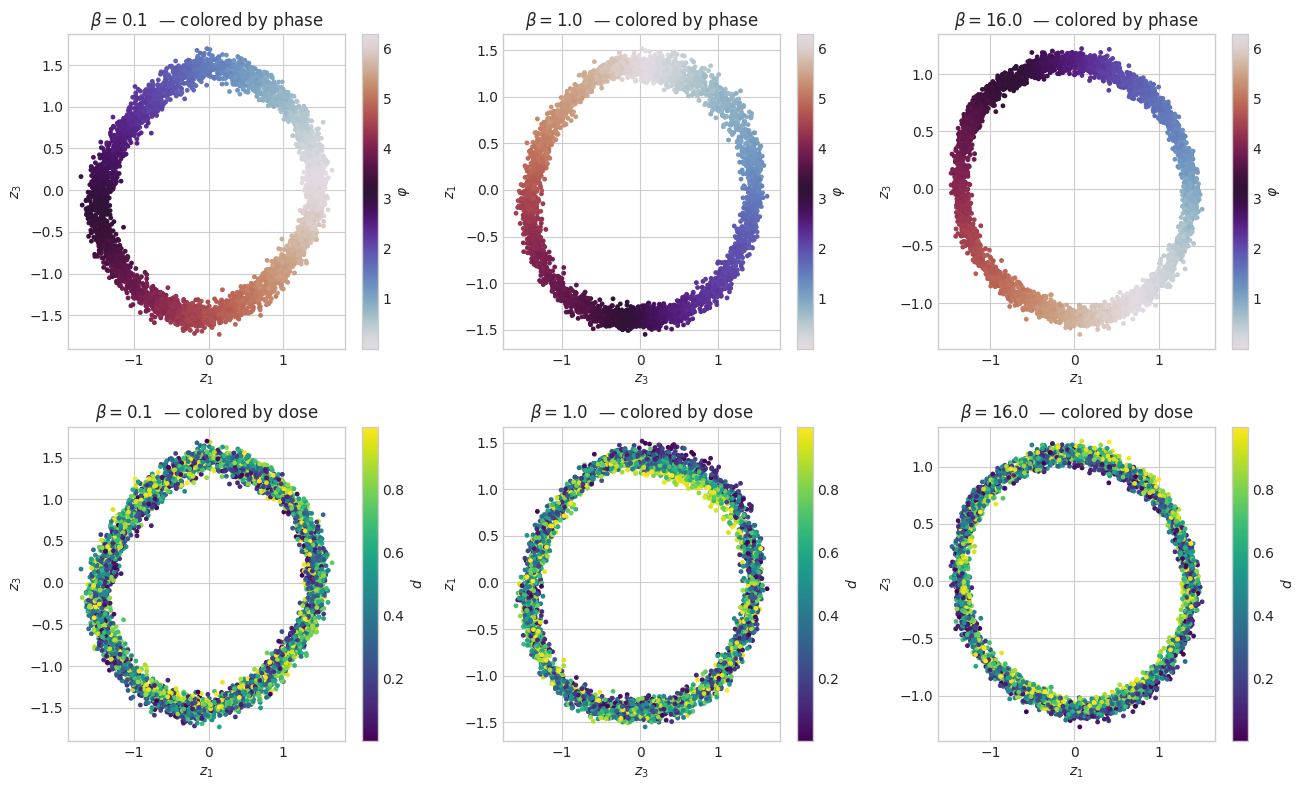

In [7]:
def active_dims(enc, x_t, k=2):
    kld = per_dim_kl(enc, x_t)
    return np.argsort(kld)[::-1][:k]

def posterior_means(enc, x_t):
    with torch.no_grad():
        mu, _ = enc(x_t)
        return mu.numpy()

show_betas = [0.1, 1.0, 16.0]
fig, axes = plt.subplots(2, len(show_betas), figsize=(4.4 * len(show_betas), 8.0))
for col, beta in enumerate(show_betas):
    enc = models[beta]['enc']
    Z = posterior_means(enc, X_t)
    a, b = active_dims(enc, X_t, 2)

    sc0 = axes[0, col].scatter(Z[:, a], Z[:, b], s=6, c=phase_true, cmap='twilight')
    axes[0, col].set_title(rf'$\beta = {beta}$  — colored by phase')
    axes[0, col].set_xlabel(rf'$z_{{{a+1}}}$'); axes[0, col].set_ylabel(rf'$z_{{{b+1}}}$')
    plt.colorbar(sc0, ax=axes[0, col], label=r'$\varphi$')

    sc1 = axes[1, col].scatter(Z[:, a], Z[:, b], s=6, c=dose_true, cmap='viridis')
    axes[1, col].set_title(rf'$\beta = {beta}$  — colored by dose')
    axes[1, col].set_xlabel(rf'$z_{{{a+1}}}$'); axes[1, col].set_ylabel(rf'$z_{{{b+1}}}$')
    plt.colorbar(sc1, ax=axes[1, col], label=r'$d$')

plt.tight_layout(); plt.show()

## Step 7: Quantifying Disentanglement

Visual inspection only goes so far. Two more rigorous diagnostics:

**(a) Predictability of each true factor from each latent.** For every $(k, f)$ pair we fit a univariate predictor of factor $f$ from latent $z_k$ and report its $R^2$ on held-out cells. A *disentangled* model has each row dominated by one column (one factor per latent) and each column dominated by one row (one latent per factor).

For phase we regress two outputs $(\sin\varphi, \cos\varphi)$ jointly (phase lives on a circle) and report the average $R^2$ across the two. For dose we just regress $d$.

**(b) Total correlation of the aggregated posterior** (Eq. 21.25). We estimate $p(\mathbf{z})$ by collecting samples $z^{(n)} \sim q_{\boldsymbol{\phi}}(\mathbf{z}\mid \mathbf{x}^{(n)})$ for every training cell, then approximate both $\mathbb{H}(\mathbf{z})$ and $\sum_k \mathbb{H}(z_k)$ via a multivariate Gaussian fit — the standard “continuous” TC estimator. The Gaussian assumption isn't exact (aggregated posteriors are mixtures), but it gives a consistent number for comparing $\beta$ values.

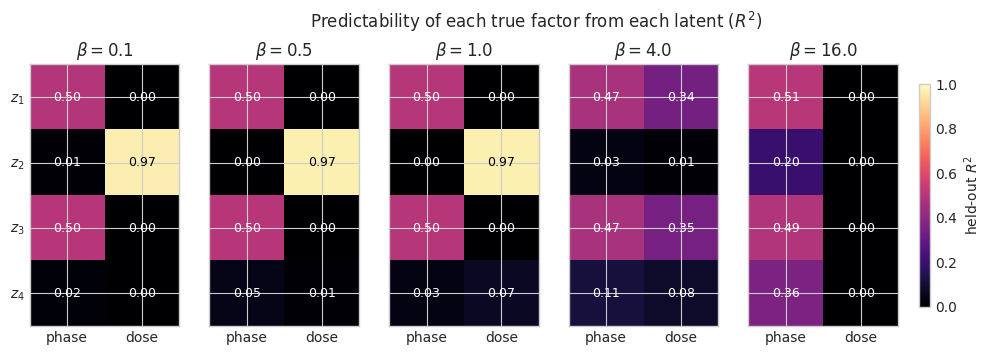

In [8]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

def r2_matrix(Z, phase, dose, deg=3):
    # Polynomial-feature regression so a single latent can capture nonlinear factor responses.
    n_latent = Z.shape[1]
    R2 = np.zeros((n_latent, 2))    # cols: phase, dose
    Z_tr, Z_te, ph_tr, ph_te, do_tr, do_te = train_test_split(
        Z, phase, dose, test_size=0.3, random_state=0
    )
    sin_tr, cos_tr = np.sin(ph_tr), np.cos(ph_tr)
    sin_te, cos_te = np.sin(ph_te), np.cos(ph_te)
    for k in range(n_latent):
        feats_tr = np.stack([Z_tr[:, k]**p for p in range(1, deg + 1)], axis=1)
        feats_te = np.stack([Z_te[:, k]**p for p in range(1, deg + 1)], axis=1)

        # phase: regress (sin, cos) jointly, report mean R^2
        m = Ridge(alpha=1.0).fit(feats_tr, np.stack([sin_tr, cos_tr], axis=1))
        pred = m.predict(feats_te)
        ss_res = ((np.stack([sin_te, cos_te], axis=1) - pred) ** 2).sum(0)
        ss_tot = ((np.stack([sin_te, cos_te], axis=1) - np.array([sin_te.mean(), cos_te.mean()])) ** 2).sum(0)
        R2[k, 0] = 1.0 - (ss_res / ss_tot).mean()

        # dose
        m = Ridge(alpha=1.0).fit(feats_tr, do_tr)
        pred = m.predict(feats_te)
        R2[k, 1] = 1.0 - ((do_te - pred) ** 2).sum() / ((do_te - do_te.mean()) ** 2).sum()
    return np.clip(R2, 0.0, 1.0)

fig, axes = plt.subplots(1, len(betas), figsize=(2.6 * len(betas) + 0.5, 3.4), sharey=True)
for ax, beta in zip(axes, betas):
    Z = posterior_means(models[beta]['enc'], X_t)
    R2 = r2_matrix(Z, phase_true, dose_true)
    im = ax.imshow(R2, vmin=0, vmax=1, cmap='magma', aspect='auto')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['phase', 'dose'])
    ax.set_yticks(range(K)); ax.set_yticklabels([rf'$z_{k+1}$' for k in range(K)])
    ax.set_title(rf'$\beta = {beta}$')
    for i in range(K):
        for j in range(2):
            ax.text(j, i, f'{R2[i, j]:.2f}', ha='center', va='center',
                    color='white' if R2[i, j] < 0.6 else 'black', fontsize=9)
fig.colorbar(im, ax=axes, label=r'held-out $R^2$', shrink=0.85, pad=0.02)
fig.suptitle(r'Predictability of each true factor from each latent ($R^2$)', y=1.04)
plt.show()

## Step 7: Quantifying Disentanglement

Visual inspection only goes so far. Two more rigorous diagnostics:

**(a) Predictability of each true factor from each latent.** For every $(k, f)$ pair we fit a univariate predictor of factor $f$ from latent $z_k$ and report its $R^2$ on held-out cells. A *disentangled* model has each row dominated by one column (one factor per latent) and each column dominated by one row (one latent per factor).

For phase we regress two outputs $(\sin\varphi, \cos\varphi)$ jointly (phase lives on a circle) and report the average $R^2$ across the two. For dose we just regress $d$.

**(b) Total correlation of the aggregated representation** (Eq. 21.25). We collect the *posterior means* $\boldsymbol{\mu}_{\boldsymbol{\phi}}(\mathbf{x}^{(n)})$ across all training cells and approximate both $\mathbb{H}(\mathbf{z})$ and $\sum_k \mathbb{H}(z_k)$ via a multivariate Gaussian fit. Using means rather than samples is deliberate: the deterministic $\boldsymbol{\mu}$ carries the *structural* representation that downstream tasks see; the per-cell Gaussian noise added during sampling washes out exactly the linear correlations TC is meant to detect. Note this is a Gaussian *linear-correlation* lower bound on the true TC — sufficient to track the trend across $\beta$.

β =  0.10  active dims = 3  Gaussian-TC of posterior means = 0.005 nats
β =  0.50  active dims = 3  Gaussian-TC of posterior means = 0.002 nats
β =  1.00  active dims = 3  Gaussian-TC of posterior means = 0.001 nats
β =  4.00  active dims = 2  Gaussian-TC of posterior means = 0.000 nats
β = 16.00  active dims = 2  Gaussian-TC of posterior means = 0.002 nats


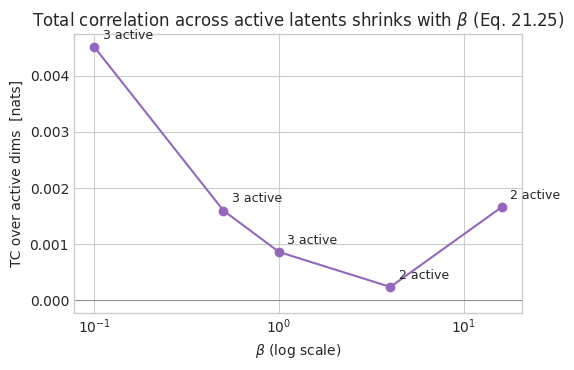

In [9]:
def gaussian_total_correlation(samples):
    # TC = sum_k H(z_k) - H(z) under a multivariate-Gaussian fit.
    if samples.shape[1] < 2:
        return 0.0
    cov = np.cov(samples, rowvar=False)
    var = np.diag(cov)
    sign, logdet = np.linalg.slogdet(cov)
    if sign <= 0:
        return float('nan')
    H_joint = 0.5 * (samples.shape[1] * np.log(2 * np.pi * np.e) + logdet)
    H_marg  = 0.5 * (np.log(2 * np.pi * np.e) + np.log(var)).sum()
    return H_marg - H_joint

def active_dim_mask(enc, x_t, kl_threshold=0.1):
    # Use per-dim KL — the same diagnostic as Step 5 — to identify dims the model actually uses.
    return per_dim_kl(enc, x_t) > kl_threshold

tc_vals = []
n_active = []
for beta in betas:
    enc = models[beta]['enc']
    mask = active_dim_mask(enc, X_t)
    means = posterior_means(enc, X_t)[:, mask]
    tc = gaussian_total_correlation(means)
    tc_vals.append(tc)
    n_active.append(int(mask.sum()))
    print(f"β = {beta:>5.2f}  active dims = {int(mask.sum())}  Gaussian-TC of posterior means = {tc:.3f} nats")

fig, ax = plt.subplots(figsize=(5.8, 3.8))
ax.plot(betas, tc_vals, '-o', color='#9467bd')
for b, tc, nact in zip(betas, tc_vals, n_active):
    ax.annotate(f'{nact} active', (b, tc),
                textcoords='offset points', xytext=(6, 6), fontsize=9)
ax.set_xscale('log')
ax.set_xlabel(r'$\beta$ (log scale)')
ax.set_ylabel('TC over active dims  [nats]')
ax.set_title(r'Total correlation across active latents shrinks with $\beta$ (Eq. 21.25)')
ax.axhline(0, color='gray', lw=0.6)
plt.tight_layout(); plt.show()

## Step 8: Latent Traversals

Another classic disentanglement test: pick an “anchor” cell, then **sweep one latent dimension** while holding the others fixed, decode, and visualize the resulting gene-expression vector. If the latent is disentangled, traversing $z_a$ should move only along the *phase* manifold (genes oscillate) and traversing $z_b$ should move only along the *dose* manifold (genes shift monotonically).

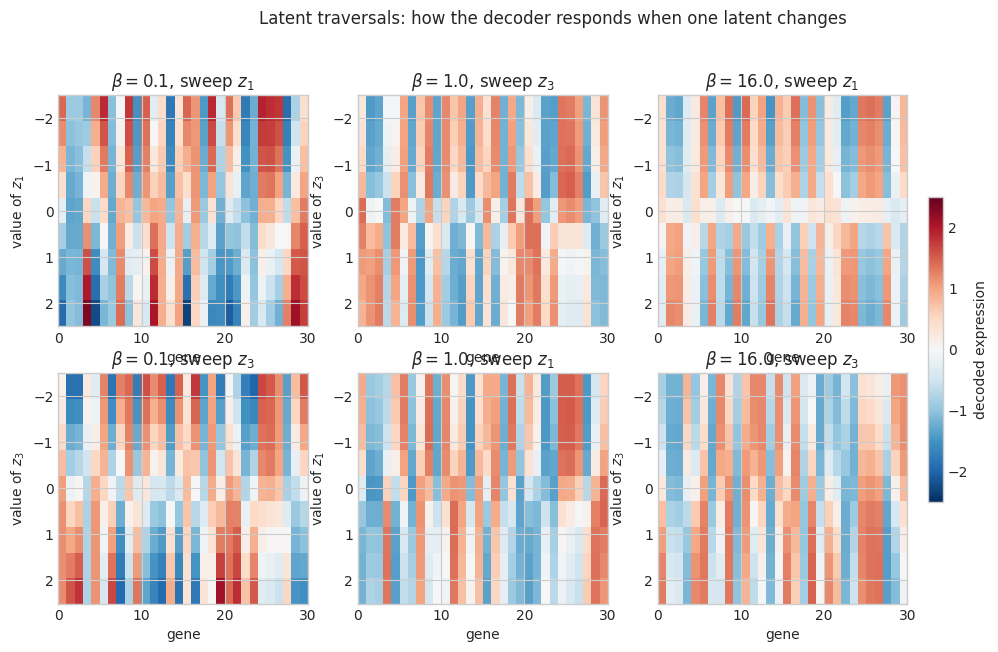

In [10]:
anchor_idx = 0
sweep_vals = np.linspace(-2.5, 2.5, 9)

fig, axes = plt.subplots(2, len(show_betas), figsize=(4.4 * len(show_betas), 6.6))
for col, beta in enumerate(show_betas):
    enc, dec = models[beta]['enc'], models[beta]['dec']
    a, b = active_dims(enc, X_t, 2)
    with torch.no_grad():
        mu_anchor, _ = enc(X_t[anchor_idx:anchor_idx + 1])
        mu_anchor = mu_anchor.squeeze(0).clone()
        for row, dim in enumerate([a, b]):
            traversals = []
            for v in sweep_vals:
                z = mu_anchor.clone()
                z[dim] = float(v)
                traversals.append(dec(z.unsqueeze(0)).squeeze(0).numpy())
            traversals = np.stack(traversals)               # (len(sweep_vals), D)
            im = axes[row, col].imshow(traversals, aspect='auto', cmap='RdBu_r',
                                       vmin=-2.5, vmax=2.5,
                                       extent=[0, D, sweep_vals[-1], sweep_vals[0]])
            axes[row, col].set_xlabel('gene')
            axes[row, col].set_ylabel(rf'value of $z_{{{dim+1}}}$')
            axes[row, col].set_title(rf'$\beta = {beta}$, sweep $z_{{{dim+1}}}$')
fig.colorbar(im, ax=axes, label='decoded expression', shrink=0.6, pad=0.02)
fig.suptitle('Latent traversals: how the decoder responds when one latent changes', y=1.01)
plt.show()

Read the rows top-to-bottom. With a small $\beta$ both rows look similar — the model has tied the two latents together. With $\beta = 16$ the two rows should look qualitatively different: one shows an oscillatory pattern across genes (the phase axis), the other a monotonic shift (the dose axis).

## A Caveat from §21.3.1.1: Identifiability

The book is careful to point out (citing Locatello et al. 2018) that **disentanglement is not identifiable from data alone**: for any disentangled representation there is an equivalent fully-entangled one with the same likelihood. What lets our experiment work at all is the inductive bias of the *encoder* (a small MLP), the *decoder* (likewise), and the *prior* (factorized Gaussian) — plus the smoothness of how our synthetic data depends on phase and dose. Change those, and the same $\beta$ value may give you nothing useful. So $\beta$ is *necessary* for disentanglement under this loss but not *sufficient* on its own.

## Connection with the information bottleneck (§21.3.1.2)

The book also notes that $\beta$-VAE is the unsupervised version of the **information bottleneck** with $\tilde{\mathbf{x}} = \mathbf{x}$:
$$\mathcal{L}_{\mathrm{UVIB}} = \beta\, \mathbb{I}(\mathbf{z}; \mathbf{x}) - \mathbb{I}(\mathbf{z}; \tilde{\mathbf{x}}).$$

In words: pick a representation $\mathbf{z}$ that is informative about a target ($\tilde{\mathbf{x}}$) while not memorizing too much about $\mathbf{x}$. The KL term we just controlled with $\beta$ is an upper bound on $\mathbb{I}(\mathbf{z};\mathbf{x})$ — so cranking up $\beta$ literally restricts how many bits of information about the input the model is allowed to keep in the latent.

## Summary

### What we built
A $\beta$-VAE for gene-expression data with two known but confounded latent factors (cell cycle phase and drug dose), trained at five values of $\beta$ so we could trace the rate–distortion curve and watch the latent representation change.

### Key takeaways from PML-2 §21.3.1
1. **One hyperparameter, one curve.** Sweeping $\beta$ moves the model along the rate–distortion curve (Eq. 21.24). Low $\beta$ → sharp reconstructions, expressive code. High $\beta$ → compressed code, smoother reconstructions.
2. **Why higher β = blurry.** Eq. 21.23 — a Gaussian decoder optimally predicts the *mean* over inputs that map to the same $\mathbf{z}$, so squeezing the latent forces averaging.
3. **Posterior collapse is selective.** With $K=4$ latents but two underlying factors, larger $\beta$ progressively collapses extra dimensions onto the prior (per-dim KL bar plot, Step 5).
4. **Disentanglement — in expectation.** $\beta > 1$ pushes the aggregated posterior toward the factorized prior, which lowers total correlation (Eq. 21.25 / Step 7) and lines latent axes up with separate factors when the inductive biases cooperate.
5. **Identifiability is the big asterisk.** §21.3.1.1 (Locatello et al.) — disentanglement is fundamentally underdetermined by the data; the architecture, prior, and dataset all do load-bearing work. $\beta$ alone is not magic.
6. **β-VAE = unsupervised IB.** The KL term is an upper bound on $\mathbb{I}(\mathbf{z}; \mathbf{x})$, so β directly controls how many bits about the input live in the latent (§21.3.1.2).